In [1]:
import FlamingoBaryonResponseEmulator as fre

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.pyplot import cm

In [3]:
# Load FLAMINGO emulator
emulator = fre.FlamingoBaryonResponseEmulator()


In [4]:
# Mode bins in [h / Mpc]
k_min = 10**-1.5
k_max = 10**1.5
num_bins_k = 121
bins_k = 10 ** (np.linspace(np.log10(k_min), np.log10(k_max), num_bins_k))
k_min_plot = 0.02
k_max_plot = 50

In [5]:
# Bins of redshifts
redshifts = np.linspace(0.0, 2.0, 11)

In [12]:
# Specify baryon model
fgas_sigma = 0.0
Mstar_sigma = 0.0
jet_fraction = 1.0


Text(0.03794733192202055, 1.13, '${\\rm fgas}+0\\sigma$\n${\\rm M*}+0\\sigma$\n${\\rm JET}~0\\%$')

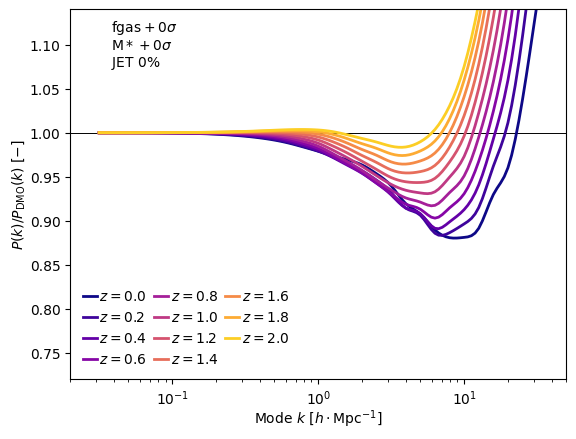

In [13]:
# Prepare figure
ax = plt.subplot()
ax.set_xscale("log")
ax.hlines(1, 1e-4, 1e4, ls="-", color="k", lw=0.7)

colors_z = cm.plasma(np.linspace(0.0, 0.9, len(redshifts)))

# Plot emulator data
for i in range(np.size(redshifts)):

    # Call emulator
    response = emulator.predict(
        bins_k, redshifts[i], fgas_sigma, Mstar_sigma, jet_fraction
    )

    # Plot response
    ax.plot(
        bins_k,
        response,
        color=colors_z[i],
        label="$z=%.1f$" % redshifts[i],
        lw=2,
        ms=1.5,
    )

# Plot range
ax.set_xlim(k_min_plot, k_max_plot)
ax.set_ylim(0.72, 1.14)
ax.set_ylabel("$P(k) / P_{\\rm DMO}(k)~[-]$", labelpad=2)
ax.set_xlabel("${\\rm Mode}~k~[h\\cdot{\\rm Mpc}^{-1}]$", labelpad=0)

# Legend and model
legend = ax.legend(
    loc="lower left",
    fancybox=True,
    framealpha=1,
    handlelength=1,
    ncol=3,
    columnspacing=0.5,
    handletextpad=0.2,
)
legend.get_frame().set_edgecolor("white")
ax.text(
    k_min * 1.2,
    1.13,
    "${\\rm fgas}+0\\sigma$\n${\\rm M*}+0\\sigma$\n${\\rm JET}~0\\%$",
    va="top",
    ha="left",
)